In [10]:
import numpy as np
import pandas as pd
from tensorflow import keras
import seaborn as sns
import matplotlib.pyplot as plt
from keras import layers
from sklearn.preprocessing import StandardScaler
import numpy as np
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from metrics_tracking import F1Score, plot_metrics


In [11]:
#import the datasets to test
def load_data(data_file_name):
    data = np.load(f"Preprocessed_Data/{data_file_name}")
    # Access arrays by their keys
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_test  = data["X_test"]
    y_test  = data["y_test"]
    X_train = X_train[..., :-1] #TEMP FIX REMOVE LATER - FIX PREPROCESSING TO GET RID OF STRING COLUMN
    X_test  = X_test[..., :-1] #TEMP FIX REMOVE LATER
    print(X_train.shape)
    print(y_train.shape)
    print(X_test.shape)
    print(y_test.shape)
    data.close()
    return X_train, y_train, X_test, y_test

data_file_name = "roads_canids_windows_200hz_3s.npz"
X_train, y_train, X_test, y_test = load_data(data_file_name)

(11280, 600, 23)
(11280,)
(13948, 600, 23)
(13948,)


In [12]:
def standardize(X_train, y_train, X_test, y_test):
    # Clip outliers 
    X_train = np.clip(X_train, -1e6, 1e6)
    X_test  = np.clip(X_test,  -1e6, 1e6)
    # Standardize features
    scaler = StandardScaler()
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_test_flat  = X_test.reshape(-1,  X_test.shape[-1])
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_test_scaled  = scaler.transform(X_test_flat)
    X_train = X_train_scaled.reshape(X_train.shape)
    X_test  = X_test_scaled.reshape(X_test.shape)
    return X_train, y_train, X_test, y_test
X_train, y_train, X_test, y_test = standardize(X_train, y_train, X_test, y_test)

In [13]:
def create_model_road(): #this is the same model we'll always use for all. 
    model = keras.Sequential()
    model.add(layers.Input(shape=(600, 23)))
    model.add(layers.Conv1D(128, 8, activation='relu'))
    model.add(layers.GlobalAveragePooling1D()) #was GlobalMaxPooling1D
    model.add(layers.Dense(1, activation='sigmoid')) #output 1 bc we only have 2 labels: attack or not attack
    return model
model = create_model_road()

In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 593, 128)       │        23,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,809 (93.00 KB)

 Trainable params: 23,809 (93.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#train data 
b_size = 32
callbacks = [
    ModelCheckpoint("saved_models/best_model_road_128cnn.keras", monitor='val_auc', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=8, min_lr=1e-11, verbose=1),
    EarlyStopping(monitor='val_auc', patience=10, verbose=1, restore_best_weights=True)
]
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss = 'binary_crossentropy', 
              metrics = ['accuracy', keras.metrics.AUC(name='auc'), 
              keras.metrics.Precision(name='precision'),
              keras.metrics.Recall(name='recall'),
              F1Score(name="f1")
])
history = model.fit(X_train, y_train, batch_size = b_size, epochs = 50, validation_split=0.1, callbacks = callbacks, verbose = 1)

Epoch 1/50
315/318 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9345 - auc: 0.9090 - f1: 0.3083 - loss: 0.1810 - precision: 0.4491 - recall: 0.2503
Epoch 1: val_auc improved from None to 0.82659, saving model to saved_models/best_model_road_128cnn.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9568 - auc: 0.9677 - f1: 0.5345 - loss: 0.1093 - precision: 0.6866 - recall: 0.4375 - val_accuracy: 0.7234 - val_auc: 0.8266 - val_f1: 0.6031 - val_loss: 0.5622 - val_precision: 0.8007 - val_recall: 0.4837 - learning_rate: 0.0010
Epoch 2/50
315/318 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9735 - auc: 0.9914 - f1: 0.7473 - loss: 0.0593 - precision: 0.7883 - recall: 0.7120
Epoch 2: val_auc improved from 0.82659 to 0.88056, saving model to saved_models/best_model_road_128cnn.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9763 - auc: 0.9928 - f1: 0.7811 - loss: 0.0552 - precision: 0.8190 - recall: 0.7465 - val_accuracy: 0.8369 - val_auc: 0.8806 - val_f1: 0.7895

In [16]:
def print_test_metrics(X_test, y_test, model):
    testing_acc = model.evaluate(X_test,y_test, verbose=1)
    print(f"Test loss: {testing_acc[0]}")
    print(f"Test accuracy: {testing_acc[1]}")
    print(f"Test AUC: {testing_acc[2]}")
    print(f"Test Precision: {testing_acc[3]}")
    print(f"Test Recall: {testing_acc[4]}")
    print(f"Test F1: {testing_acc[5]}")
print_test_metrics(X_test, y_test, model)

436/436 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9895 - auc: 0.8687 - f1: 0.6840 - loss: 0.0874 - precision: 0.9753 - recall: 0.5267              
Test loss: 0.08741787075996399
Test accuracy: 0.9895325303077698
Test AUC: 0.8687206506729126
Test Precision: 0.9753086566925049
Test Recall: 0.5266666412353516
Test F1: 0.6839826107025146


In [17]:
model_save_name = "best_ROAD_model128.keras"
model.save(f"saved_models/{model_save_name}")

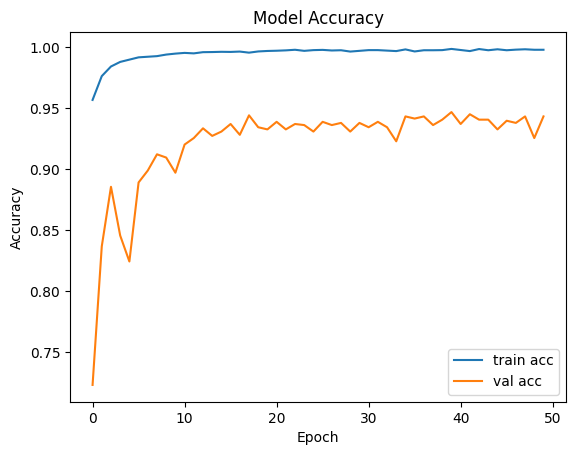

In [25]:
# plot_metrics(history, model_save_name)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [19]:
def print_report_and_score(model, X_test, y_test):
    y_pred_probs = model.predict(X_test).ravel()     # shape: (N,)
    y_pred = (y_pred_probs >= 0.5).astype(int)       # threshold
    print(classification_report(y_test, y_pred, target_names=["Ambient", "Attack"]))
    # --- Correct ROC-AUC for binary classifier ---
    roc_auc = roc_auc_score(y_test, y_pred_probs)
    print(f"ROC AUC Score: {roc_auc:.4f}")
    return y_pred
y_pred = print_report_and_score(model, X_test, y_test)

436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

     Ambient       0.99      1.00      0.99     13648
      Attack       0.98      0.53      0.68       300

    accuracy                           0.99     13948
   macro avg       0.98      0.76      0.84     13948
weighted avg       0.99      0.99      0.99     13948

ROC AUC Score: 0.9940


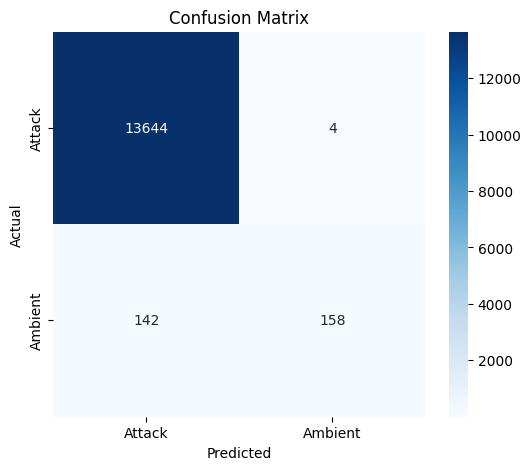

<Figure size 640x480 with 0 Axes>

In [22]:
def display_confusion_matrix(y_test, y_pred, model_name="best_ROAD_model128.keras"):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=["Attack", "Ambient"],
        yticklabels=["Attack", "Ambient"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
    plt.savefig(f"{model_name}_confusion_matrix.png")
display_confusion_matrix(y_test, y_pred, model_save_name)

436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


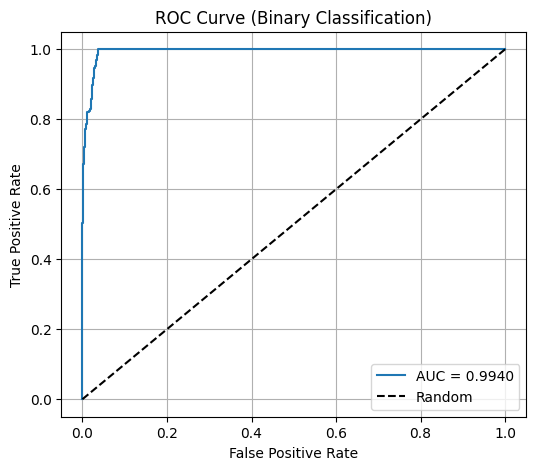

In [21]:
from sklearn.metrics import roc_curve


y_pred_proba = model.predict(X_test).ravel()   # shape (N,)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary Classification)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()